FRED 서버에서 CPI 데이터를 가져오는 중...
✅ 데이터 저장 완료! (컬럼명: CPIAUCSL)


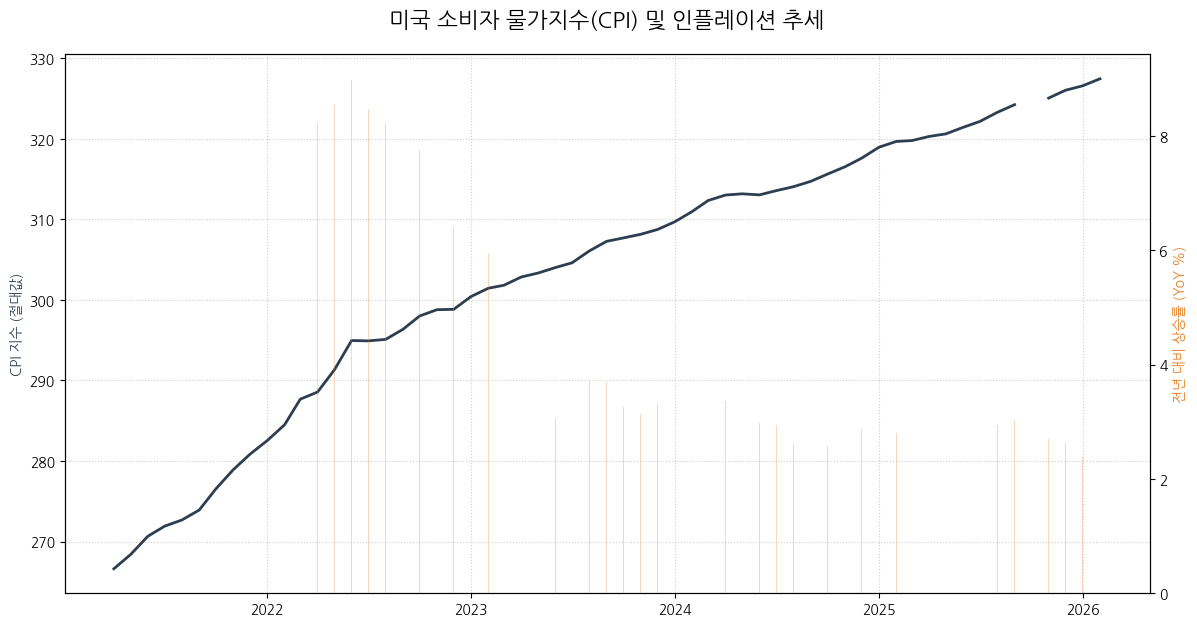

최근 데이터 날짜: 2026-02-01
최근 인플레이션율(YoY): 2.43%


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from datetime import datetime, timedelta

# 1. 데이터 수집 (FRED 공식 CSV 링크)
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"

print("FRED 서버에서 CPI 데이터를 가져오는 중...")

# index_col=0 으로 설정하여 첫 번째 열(날짜)을 자동으로 인덱스로 사용
df = pd.read_csv(url, index_col=0, parse_dates=True)

# 2. 데이터 필터링 (최근 5년)
start_date = datetime.now() - timedelta(days=5*365)
df = df[df.index >= start_date]

# 3. 데이터 컬럼 이름 정리 (안정성을 위해 강제 지정)
# FRED 데이터는 보통 컬럼명이 'CPIAUCSL'이지만, 범용성을 위해 첫 컬럼을 선택
cpi_col_name = df.columns[0] 
df['CPI_YoY'] = df[cpi_col_name].pct_change(12) * 100

# 4. CSV 저장
df.to_csv("us_cpi_5yr_final.csv")
print(f"✅ 데이터 저장 완료! (컬럼명: {cpi_col_name})")

# 5. 시각화
fig, ax1 = plt.subplots(figsize=(14, 7))

# CPI 지수 (선 그래프)
ax1.plot(df.index, df[cpi_col_name], color='#2C3E50', linewidth=2, label='CPI 지수')
ax1.set_ylabel('CPI 지수 (절대값)', color='#2C3E50')

# 상승률 (막대 그래프)
ax2 = ax1.twinx()
ax2.bar(df.index, df['CPI_YoY'], color='#E67E22', alpha=0.3, label='인플레이션율(YoY)')
ax2.set_ylabel('전년 대비 상승률 (YoY %)', color='#E67E22')

plt.title('미국 소비자 물가지수(CPI) 및 인플레이션 추세', fontsize=16, pad=20)
ax1.grid(True, linestyle=':', alpha=0.6)
plt.show()

# 6. 최신 결과 출력
print(f"최근 데이터 날짜: {df.index[-1].strftime('%Y-%m-%d')}")
print(f"최근 인플레이션율(YoY): {df['CPI_YoY'].dropna().iloc[-1]:.2f}%")